In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import special_ortho_group

def generate_eigenvalues(ranges: list[tuple], nums: list, rng):
    groups = []
    for range, num in zip(ranges, nums):
        groups.append(rng.random(num) * (range[1] - range[0]) + range[0])
        
    return np.diag(np.concat(groups))

def plot_eigenvalues(lamb):
    plt.hist(np.linalg.eigvals(lamb))
    plt.show()
    
def random_rotation(d, rng, n=1):
    group = special_ortho_group(dim=d, seed=rng.integers(0, 100))
    return group.rvs(n)

def gradient(Q, theta, x):
    return np.dot(Q, theta - x)

def objective(Q, theta, target, noise):
    return np.dot(0.5 * (theta - target), np.dot(Q, theta - target)) + ((noise ** 2) / 2) * np.linalg.trace(Q)

def sample_data(target, noise, rng, n=1):
    return rng.normal(0, noise, size=n*target.shape[0]).reshape(n, -1) + target


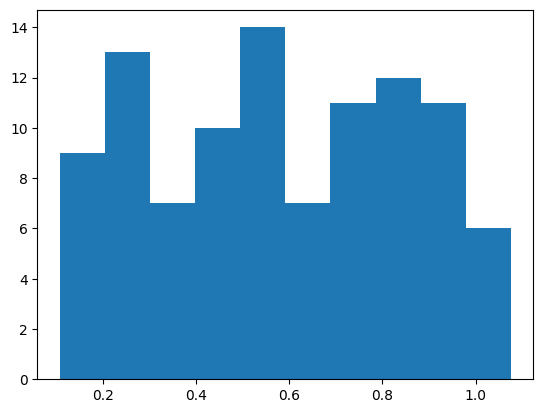

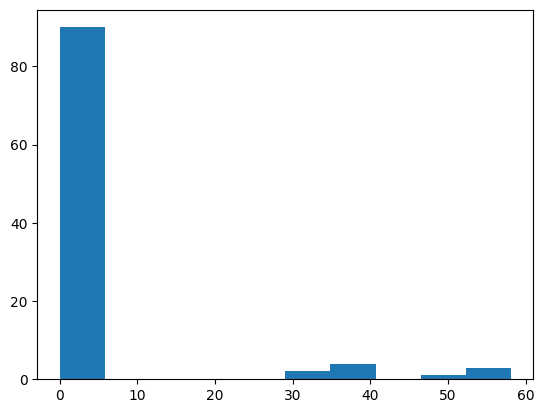

In [63]:
seed = 42
rng = np.random.default_rng(seed)

lamb1 = generate_eigenvalues([(0.1, 1.1)], [100], rng)
plot_eigenvalues(lamb1)
lamb2 = generate_eigenvalues([(0, 1), (30, 60)], [90, 10], rng)
plot_eigenvalues(lamb2)

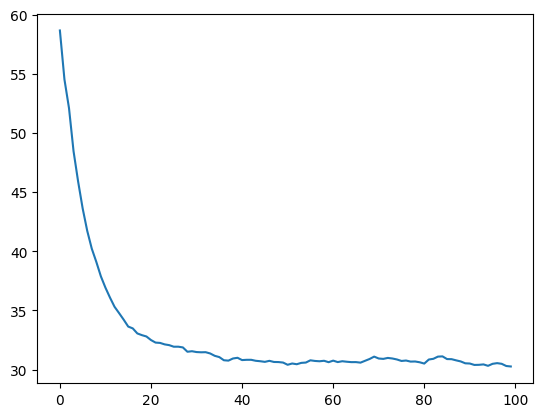

In [94]:
target = np.ones(100)
noise = 1
Q = lamb1
data = sample_data(target, noise, rng, n=100)
theta = np.zeros(100)
objectives = []
for d in data:
    objectives.append(objective(Q, theta, target, noise))
    grad = gradient(Q, theta, d)
    theta -= grad * 1e-1

plt.plot(objectives)
    